Raw neural shape: (106087, 175)
Raw syllables shape: (106087,)
Train timepoints: 79565
Test timepoints: 26522
PC data shape: (106087, 10)
Explained variance ratio: [0.03201659 0.02786422 0.02319822 0.02095216 0.01943406 0.01773685
 0.01685271 0.0163333  0.0157344  0.01520637]
Cumulative explained variance: [0.03201659 0.05988082 0.08307903 0.10403119 0.12346525 0.14120209
 0.1580548  0.1743881  0.1901225  0.20532887]
Train transitions: 79564
Test transitions: 26522
Using device: cuda
Epoch 000 | Train loss: 3.645179 | Test TF loss: 1.603361
Epoch 020 | Train loss: 1.435171 | Test TF loss: 0.654565
Epoch 040 | Train loss: 0.172777 | Test TF loss: 0.106326
Epoch 060 | Train loss: 0.063347 | Test TF loss: 0.045938
Epoch 080 | Train loss: 0.034357 | Test TF loss: 0.026673
Epoch 100 | Train loss: 0.025732 | Test TF loss: 0.021791
Epoch 120 | Train loss: 0.021961 | Test TF loss: 0.019264
Epoch 140 | Train loss: 0.020228 | Test TF loss: 0.017896
Epoch 160 | Train loss: 0.018834 | Test TF loss

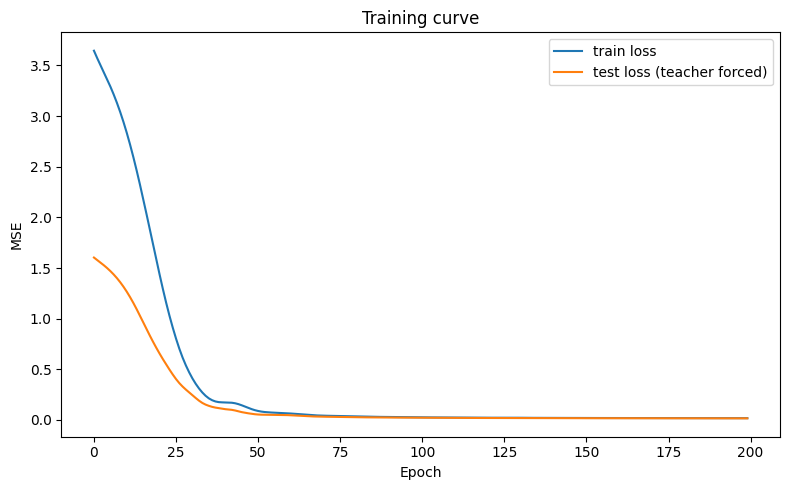

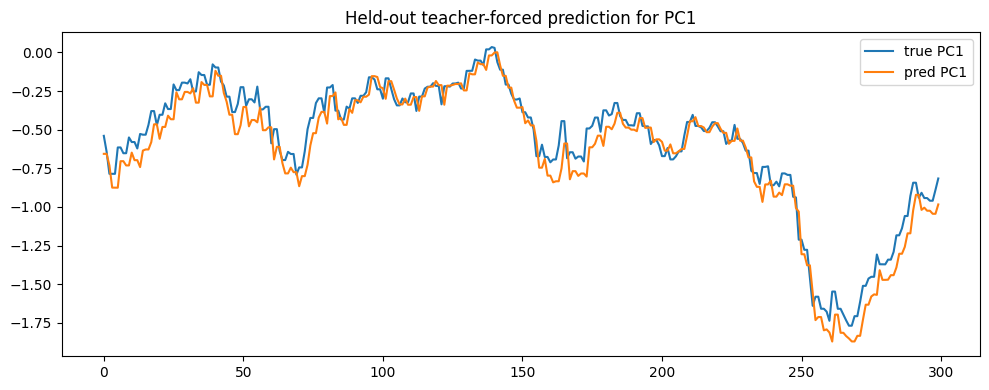

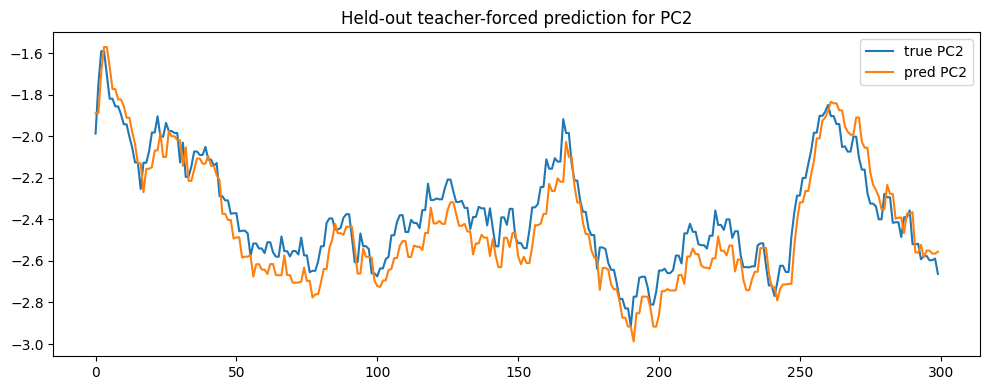

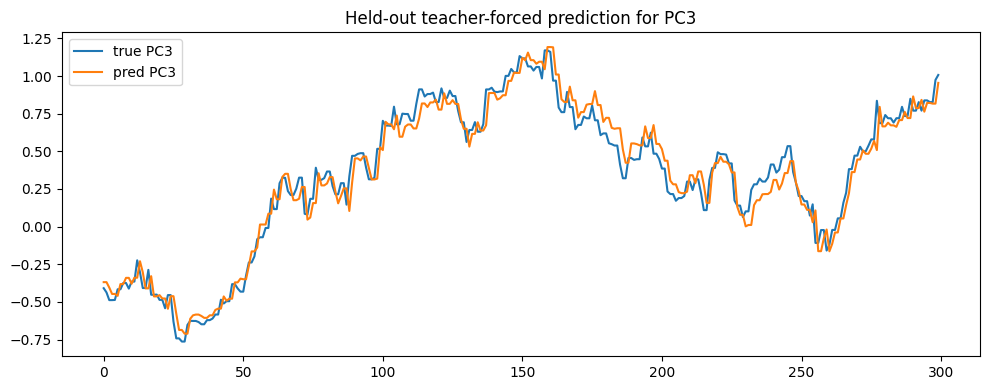

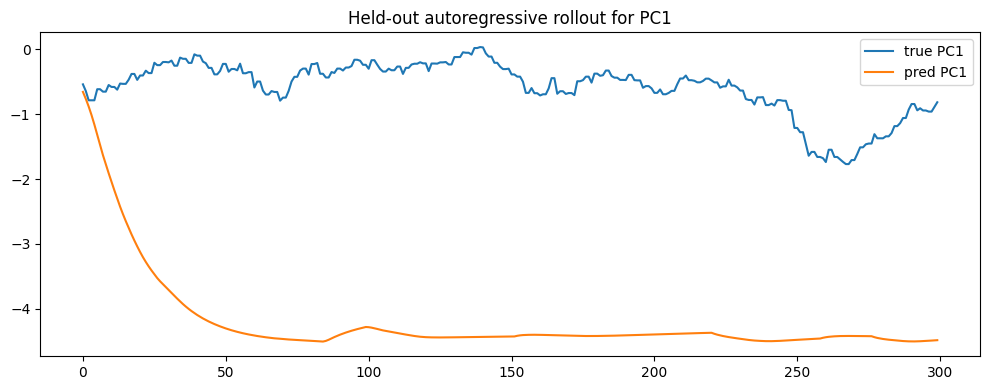

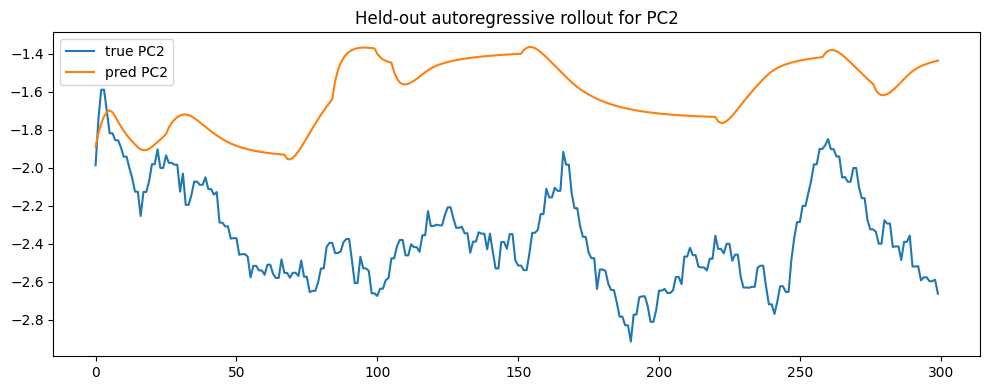

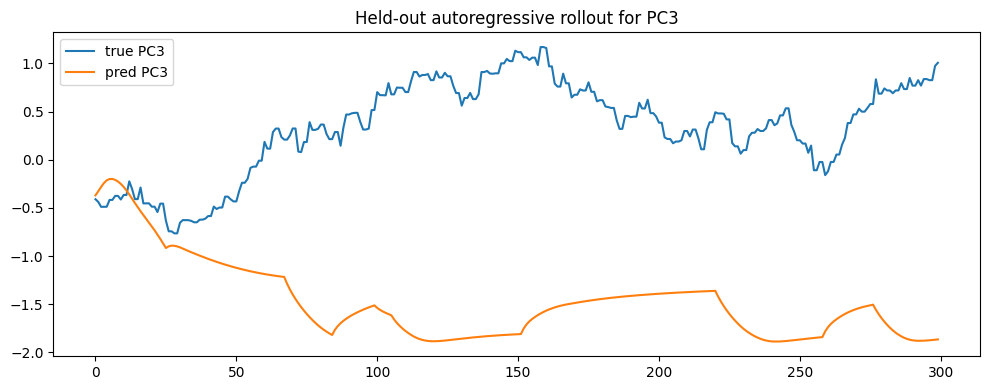

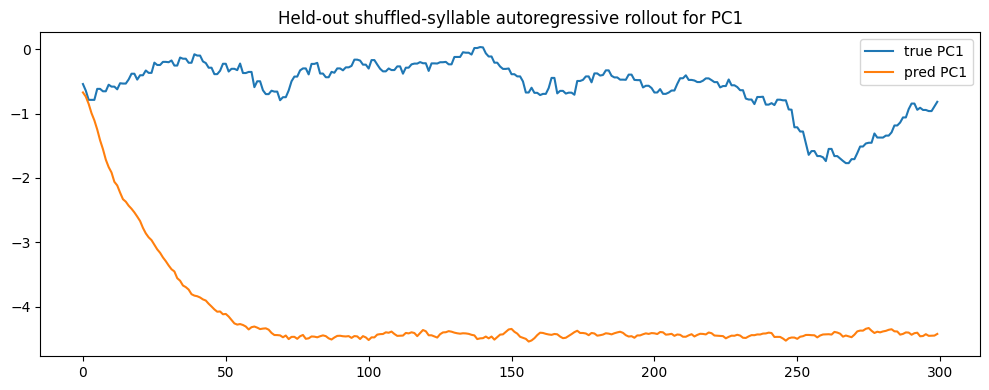

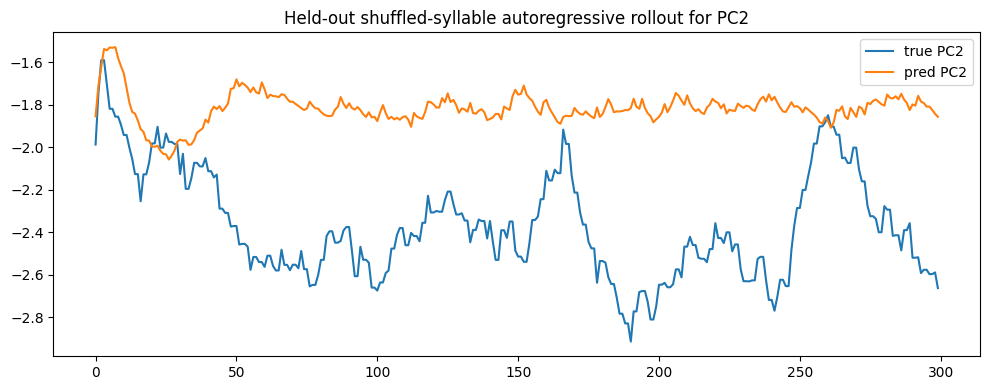

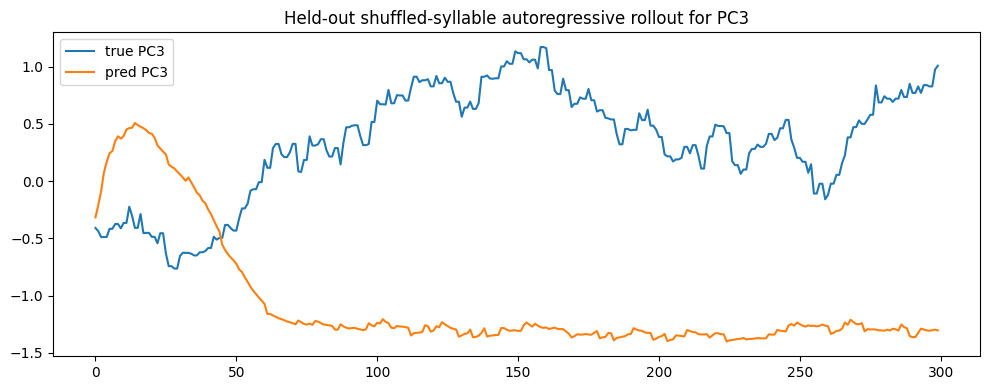

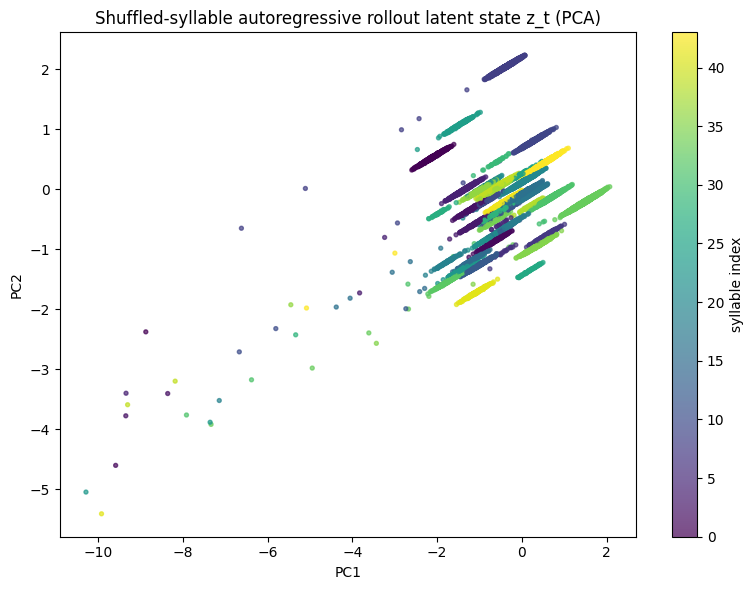

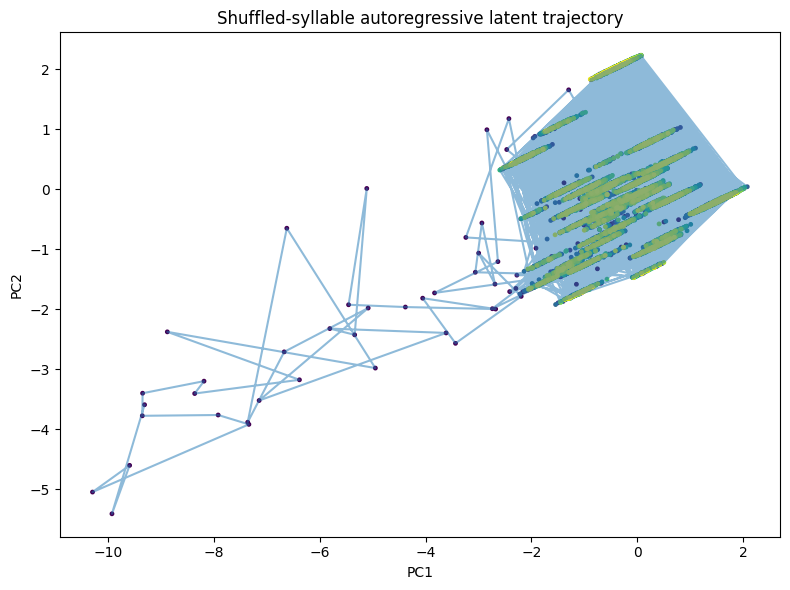

Done.


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


class SyllablePCModel(nn.Module):
    def __init__(self, n_pcs, n_syllables, emb_dim=16, hidden_dim=128):
        super().__init__()

        self.syll_embedding = nn.Embedding(n_syllables, emb_dim)

        self.pc_encoder = nn.Sequential(
            nn.Linear(n_pcs, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim + emb_dim, hidden_dim),
            nn.ReLU(),
        )

        self.predict_next_pc = nn.Linear(hidden_dim, n_pcs)

    def forward(self, x_t, syll_t):
        e_t = self.syll_embedding(syll_t)
        h_t = self.pc_encoder(x_t)
        z_t = self.fusion(torch.cat([h_t, e_t], dim=-1))
        x_next_pred = self.predict_next_pc(z_t)
        return x_next_pred, z_t, e_t


def make_transition_split(neural_pcs, syllables_idx, train_frac=0.75):
    x_t = neural_pcs[:-1].astype(np.float32)
    x_tp1 = neural_pcs[1:].astype(np.float32)
    syll_t = syllables_idx[:-1].astype(np.int64)

    n_transitions = len(x_t)
    split_idx = int(train_frac * n_transitions)

    return {
        "train": {
            "x_t": x_t[:split_idx],
            "syll_t": syll_t[:split_idx],
            "x_tp1": x_tp1[:split_idx],
        },
        "test": {
            "x_t": x_t[split_idx:],
            "syll_t": syll_t[split_idx:],
            "x_tp1": x_tp1[split_idx:],
        },
        "split_idx": split_idx,
    }


def to_torch(split_dict, device):
    return {
        "x_t": torch.tensor(split_dict["x_t"], dtype=torch.float32, device=device),
        "syll_t": torch.tensor(split_dict["syll_t"], dtype=torch.long, device=device),
        "x_tp1": torch.tensor(split_dict["x_tp1"], dtype=torch.float32, device=device),
    }


def evaluate_teacher_forced(model, x_t, syll_t, x_tp1, loss_fn):
    model.eval()
    with torch.no_grad():
        pred, z_t, e_t = model(x_t, syll_t)
        loss = loss_fn(pred, x_tp1).item()

    return {
        "loss": loss,
        "pred": pred.cpu().numpy(),
        "true": x_tp1.cpu().numpy(),
        "z": z_t.cpu().numpy(),
        "e": e_t.cpu().numpy(),
    }


def rollout_autoregressive(model, x0, syll_seq, true_future, device="cpu"):
    """
    Safe free-running rollout.
    If predictions become non-finite, returns the valid prefix only.
    """
    if len(syll_seq) != len(true_future):
        raise ValueError(
            f"Length mismatch: syll_seq has length {len(syll_seq)} "
            f"but true_future has length {len(true_future)}"
        )

    model.eval()

    preds = []
    latents = []
    embeds = []

    x_curr = torch.tensor(x0, dtype=torch.float32, device=device).unsqueeze(0)
    stopped_early = False
    stop_step = None

    with torch.no_grad():
        for t, s in enumerate(syll_seq):
            if not torch.isfinite(x_curr).all():
                stopped_early = True
                stop_step = t
                print(f"[rollout] Non-finite state at step {t}")
                break

            s_t = torch.tensor([int(s)], dtype=torch.long, device=device)
            x_next_pred, z_t, e_t = model(x_curr, s_t)

            if not torch.isfinite(x_next_pred).all():
                stopped_early = True
                stop_step = t
                print(f"[rollout] Non-finite prediction at step {t}")
                break

            preds.append(x_next_pred.squeeze(0).cpu().numpy())
            latents.append(z_t.squeeze(0).cpu().numpy())
            embeds.append(e_t.squeeze(0).cpu().numpy())

            x_curr = x_next_pred

    if len(preds) == 0:
        return {
            "pred": None,
            "true": None,
            "z": None,
            "e": None,
            "loss": np.nan,
            "n_valid_steps": 0,
            "stopped_early": stopped_early,
            "stop_step": stop_step,
        }

    preds = np.stack(preds, axis=0)
    latents = np.stack(latents, axis=0)
    embeds = np.stack(embeds, axis=0)
    true_used = true_future[:len(preds)]

    mse = np.mean((preds - true_used) ** 2)

    return {
        "pred": preds,
        "true": true_used,
        "z": latents,
        "e": embeds,
        "loss": mse,
        "n_valid_steps": len(preds),
        "stopped_early": stopped_early,
        "stop_step": stop_step,
    }


def make_shuffled_syllable_rollout(model, split_data, device="cpu", seed=0):
    """
    Roll out on the held-out test segment, but shuffle test syllable order.
    """
    rng = np.random.default_rng(seed)

    x0_test = split_data["test"]["x_t"][0]
    true_test_future = split_data["test"]["x_tp1"]
    syll_test_seq = split_data["test"]["syll_t"].copy()

    shuffled_syll_seq = syll_test_seq.copy()
    rng.shuffle(shuffled_syll_seq)

    eval_shuffled = rollout_autoregressive(
        model=model,
        x0=x0_test,
        syll_seq=shuffled_syll_seq,
        true_future=true_test_future,
        device=device,
    )

    return {
        "eval": eval_shuffled,
        "original_syll_seq": syll_test_seq,
        "shuffled_syll_seq": shuffled_syll_seq,
        "seed": seed,
    }


def evaluate_many_shuffles(model, split_data, device="cpu", n_seeds=20):
    runs = []
    for seed in range(n_seeds):
        out = make_shuffled_syllable_rollout(
            model=model,
            split_data=split_data,
            device=device,
            seed=seed,
        )
        runs.append(out)

    losses = np.array([r["eval"]["loss"] for r in runs], dtype=float)
    valid_steps = np.array([r["eval"]["n_valid_steps"] for r in runs], dtype=int)

    return {
        "runs": runs,
        "losses": losses,
        "valid_steps": valid_steps,
        "mean_loss": float(np.nanmean(losses)),
        "std_loss": float(np.nanstd(losses)),
    }


def persistence_rollout_baseline(x0, horizon, true_future):
    pred = np.repeat(x0[None, :], horizon, axis=0)
    mse = np.mean((pred - true_future) ** 2)
    return {
        "pred": pred,
        "true": true_future,
        "loss": mse,
    }


def plot_predictions(true, pred, title_prefix="Test", max_points=300, n_plot_pcs=3):
    if true is None or pred is None:
        print(f"[plot_predictions] Skipping {title_prefix}: no valid predictions.")
        return

    n_pcs = true.shape[1]
    n_plot_pcs = min(n_plot_pcs, n_pcs)
    n_show = min(max_points, len(true))

    for pc_idx in range(n_plot_pcs):
        plt.figure(figsize=(10, 4))
        plt.plot(true[:n_show, pc_idx], label=f"true PC{pc_idx + 1}")
        plt.plot(pred[:n_show, pc_idx], label=f"pred PC{pc_idx + 1}")
        plt.title(f"{title_prefix} for PC{pc_idx + 1}")
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_loss_curves(train_losses, test_tf_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="train loss")
    plt.plot(test_tf_losses, label="test loss (teacher forced)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Training curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


def visualize_rollout_latent(z_np, syll_t_np, title_prefix="Autoregressive rollout latent"):
    if z_np is None:
        print(f"[visualize_rollout_latent] Skipping {title_prefix}: no valid latent states.")
        return None

    z_2d = PCA(n_components=2).fit_transform(z_np)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=syll_t_np[:len(z_2d)],
        s=8,
        alpha=0.7,
    )
    plt.colorbar(sc, label="syllable index")
    plt.title(f"{title_prefix} (PCA), colored by syllable")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(z_2d[:, 0], z_2d[:, 1], alpha=0.5)
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c=np.arange(len(z_2d)), s=6)
    plt.title(f"{title_prefix} trajectory")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    return z_2d

def visualize_shuffled_rollout_latent(z_np, syll_t_np):
    """
    Plot ONLY the shuffled rollout latent phase space.
    """
    if z_np is None:
        print("[visualize_shuffled_rollout_latent] No valid latent states to plot.")
        return None

    z_2d = PCA(n_components=2).fit_transform(z_np)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=syll_t_np[:len(z_2d)],
        s=8,
        alpha=0.7,
    )
    plt.colorbar(sc, label="syllable index")
    plt.title("Shuffled-syllable autoregressive rollout latent state z_t (PCA)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(z_2d[:, 0], z_2d[:, 1], alpha=0.5)
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c=np.arange(len(z_2d)), s=6)
    plt.title("Shuffled-syllable autoregressive latent trajectory")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    return z_2d


def main():
    # -------------------------
    # Load data
    # -------------------------
    neural = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/neural_rec.npy')
    syllables = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/moseq_syllables_aux.npy')

    print("Raw neural shape:", neural.shape)
    print("Raw syllables shape:", syllables.shape)

    if neural.ndim != 2:
        raise ValueError(f"Expected neural shape [T, n_neurons], got {neural.shape}")

    syllables = np.asarray(syllables).squeeze()
    if syllables.ndim != 1:
        raise ValueError(f"Expected syllables shape [T], got {syllables.shape}")

    if len(neural) != len(syllables):
        raise ValueError("neural and syllables must have same number of timepoints")

    unique_sylls = np.unique(syllables)
    syll_to_idx = {s: i for i, s in enumerate(unique_sylls)}
    syllables_idx = np.array([syll_to_idx[s] for s in syllables], dtype=np.int64)

    # -------------------------
    # Split in time before preprocessing
    # -------------------------
    T = len(neural)
    train_time_end = int(0.75 * T)

    neural_train = neural[:train_time_end]
    neural_test = neural[train_time_end:]

    print("Train timepoints:", len(neural_train))
    print("Test timepoints:", len(neural_test))

    # -------------------------
    # Fit scaler/PCA on train only
    # -------------------------
    scaler = StandardScaler()
    neural_train_scaled = scaler.fit_transform(neural_train)
    neural_test_scaled = scaler.transform(neural_test)

    n_pcs = 10
    pca = PCA(n_components=n_pcs)
    neural_train_pcs = pca.fit_transform(neural_train_scaled)
    neural_test_pcs = pca.transform(neural_test_scaled)

    neural_pcs = np.concatenate([neural_train_pcs, neural_test_pcs], axis=0)

    print("PC data shape:", neural_pcs.shape)
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

    # -------------------------
    # Build transitions
    # -------------------------
    split_data = make_transition_split(neural_pcs, syllables_idx, train_frac=0.75)

    print("Train transitions:", len(split_data["train"]["x_t"]))
    print("Test transitions:", len(split_data["test"]["x_t"]))

    # -------------------------
    # Torch
    # -------------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    train_torch = to_torch(split_data["train"], device)
    test_torch = to_torch(split_data["test"], device)

    # -------------------------
    # Model
    # -------------------------
    model = SyllablePCModel(
        n_pcs=n_pcs,
        n_syllables=len(unique_sylls),
        emb_dim=16,
        hidden_dim=128,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # -------------------------
    # Train
    # -------------------------
    n_epochs = 200
    train_losses = []
    test_tf_losses = []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        pred_train, _, _ = model(train_torch["x_t"], train_torch["syll_t"])
        train_loss = loss_fn(pred_train, train_torch["x_tp1"])
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_test_tf, _, _ = model(test_torch["x_t"], test_torch["syll_t"])
            test_tf_loss = loss_fn(pred_test_tf, test_torch["x_tp1"])

        train_losses.append(train_loss.item())
        test_tf_losses.append(test_tf_loss.item())

        if epoch % 20 == 0 or epoch == n_epochs - 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Train loss: {train_loss.item():.6f} | "
                f"Test TF loss: {test_tf_loss.item():.6f}"
            )

    # -------------------------
    # Final teacher-forced eval
    # -------------------------
    train_eval = evaluate_teacher_forced(
        model,
        train_torch["x_t"],
        train_torch["syll_t"],
        train_torch["x_tp1"],
        loss_fn,
    )

    test_eval_tf = evaluate_teacher_forced(
        model,
        test_torch["x_t"],
        test_torch["syll_t"],
        test_torch["x_tp1"],
        loss_fn,
    )

    # -------------------------
    # Clean autoregressive rollout
    # -------------------------
    x0_test = split_data["test"]["x_t"][0]
    syll_test_seq = split_data["test"]["syll_t"]
    true_test_future = split_data["test"]["x_tp1"]

    test_eval_rollout = rollout_autoregressive(
        model=model,
        x0=x0_test,
        syll_seq=syll_test_seq,
        true_future=true_test_future,
        device=device,
    )

    # -------------------------
    # Shuffled autoregressive rollout
    # -------------------------
    shuffled_results = make_shuffled_syllable_rollout(
        model=model,
        split_data=split_data,
        device=device,
        seed=0,
    )
    test_eval_rollout_shuffled = shuffled_results["eval"]

    # -------------------------
    # Baselines
    # -------------------------
    baseline_tf_test = np.mean(
        (split_data["test"]["x_t"] - split_data["test"]["x_tp1"]) ** 2
    )

    baseline_rollout = persistence_rollout_baseline(
        x0=x0_test,
        horizon=len(true_test_future),
        true_future=true_test_future,
    )

    shuffled_summary = evaluate_many_shuffles(
        model=model,
        split_data=split_data,
        device=device,
        n_seeds=20,
    )

    # -------------------------
    # Results
    # -------------------------
    print("\nFinal results")
    print("Train MSE:", train_eval["loss"])
    print("Held-out teacher-forced test MSE:", test_eval_tf["loss"])
    print("Held-out autoregressive rollout MSE:", test_eval_rollout["loss"])
    print("Held-out shuffled-syllable rollout MSE:", test_eval_rollout_shuffled["loss"])
    print("Teacher-forced persistence baseline MSE:", baseline_tf_test)
    print("Autoregressive persistence baseline MSE:", baseline_rollout["loss"])
    print(
        "Shuffled rollout MSE over 20 seeds: "
        f"{shuffled_summary['mean_loss']:.6f} ± {shuffled_summary['std_loss']:.6f}"
    )
    print("Shuffled rollout valid steps (seed 0):", test_eval_rollout_shuffled["n_valid_steps"])

    # -------------------------
    # Plots
    # -------------------------
    plot_loss_curves(train_losses, test_tf_losses)

    plot_predictions(
        true=test_eval_tf["true"],
        pred=test_eval_tf["pred"],
        title_prefix="Held-out teacher-forced prediction",
        max_points=300,
        n_plot_pcs=3,
    )

    plot_predictions(
        true=test_eval_rollout["true"],
        pred=test_eval_rollout["pred"],
        title_prefix="Held-out autoregressive rollout",
        max_points=300,
        n_plot_pcs=3,
    )

    # ONLY plot the PCs of the shuffled rollout
    plot_predictions(
        true=test_eval_rollout_shuffled["true"],
        pred=test_eval_rollout_shuffled["pred"],
        title_prefix="Held-out shuffled-syllable autoregressive rollout",
        max_points=300,
        n_plot_pcs=3,
    )

    visualize_shuffled_rollout_latent(
        z_np=test_eval_rollout_shuffled["z"],
        syll_t_np=shuffled_results["shuffled_syll_seq"][:test_eval_rollout_shuffled["n_valid_steps"]],
    )
    
    print("Done.")
    return {
        "model": model,
        "pca": pca,
        "scaler": scaler,
        "split_data": split_data,
        "train_eval": train_eval,
        "test_eval_tf": test_eval_tf,
        "test_eval_rollout": test_eval_rollout,
        "test_eval_rollout_shuffled": test_eval_rollout_shuffled,
        "baseline_tf_test": baseline_tf_test,
        "baseline_rollout": baseline_rollout,
        "shuffled_results": shuffled_results,
        "shuffled_summary": shuffled_summary,
        "train_losses": train_losses,
        "test_tf_losses": test_tf_losses,
    }


results = main()